# AlphaSpendingBounds: OBF and Pocock Spending Functions

This notebook tests `AlphaSpendingBounds` with O'Brien-Fleming and Pocock alpha spending functions.
Bounds are validated against:
- **Canonical bounds** (`CanonicalBounds`) — exact MVN solver, equally-spaced looks only
- **ldbounds (R)** — reference values from the `ldbounds` R package

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, multivariate_normal

from jaxpensive import CanonicalBounds, AlphaSpendingBounds

## O'Brien-Fleming Spending

The OBF spending function is:

$$\alpha^*(t) = 2\left(1 - \Phi\!\left(\frac{z_{\alpha/2}}{\sqrt{t}}\right)\right)$$

It spends almost nothing early and heavily at the final look — mirroring the conservative-early character of canonical O'Brien-Fleming boundaries.

The *spending* bounds and *canonical* OBF bounds are related in shape but not identical: the spending approach uses an approximating function rather than solving the exact MVN constraint.

In [2]:
# --- OBF spending vs canonical, K=4, alpha=0.05, two-sided ---
K, alpha = 4, 0.05

obf_spending  = AlphaSpendingBounds(K, alpha, 2, 'obf')
obf_canonical = CanonicalBounds(K, alpha, 2, 'obrien_fleming')

b_spend   = obf_spending.calculate_bounds()
b_canon   = obf_canonical.calculate_bounds()
t         = obf_spending.info_fractions

# ldbounds (R) reference: uses a different OBF normalisation (z_{alpha/4} instead of z_{alpha/2})
ldb_obf_k4 = np.array([4.3326, 2.9631, 2.3590, 2.0141])

print('OBF  K=4, alpha=0.05, two-sided')
print(f'{"Look":>4}  {"t":>6}  {"Spending":>10}  {"Canonical":>10}  {"ldbounds":>10}')
print('  ' + '-'*50)
for k in range(K):
    print(f'{k+1:>4}  {t[k]:>6.2f}  {b_spend[k]:>10.4f}  {b_canon[k]:>10.4f}  {ldb_obf_k4[k]:>10.4f}')

print()
print(f'Max |spending − canonical|: {np.max(np.abs(b_spend - b_canon)):.4f}')
print(f'Max |spending − ldbounds| : {np.max(np.abs(b_spend - ldb_obf_k4)):.4f}')

OBF  K=4, alpha=0.05, two-sided
Look       t    Spending   Canonical    ldbounds
  --------------------------------------------------
   1    0.25      3.9199      4.0485      4.3326
   2    0.50      2.7739      2.8627      2.9631
   3    0.75      2.2982      2.3374      2.3590
   4    1.00      2.0426      2.0242      2.0141

Max |spending − canonical|: 0.1286
Max |spending − ldbounds| : 0.4127


In [3]:
# Summary tables side-by-side
print('=== Spending ===')
obf_spending.summary()
print()
print('=== Canonical ===')
obf_canonical.summary()

=== Spending ===

Group Sequential Bounds — obf
  Looks : 4
  Alpha : 0.05
  Sides : 2
  --------------------------------------------
  Look   Info fraction   Lower (z)   Upper (z)
  --------------------------------------------
     1          0.2500     -3.9199      3.9199
     2          0.5000     -2.7739      2.7739
     3          0.7500     -2.2982      2.2982
     4          1.0000     -2.0426      2.0426
  --------------------------------------------

=== Canonical ===

Group Sequential Bounds — obrien_fleming
  Looks : 4
  Alpha : 0.05
  Sides : 2
  --------------------------------------------
  Look   Info fraction   Lower (z)   Upper (z)
  --------------------------------------------
     1          0.2500     -4.0485      4.0485
     2          0.5000     -2.8627      2.8627
     3          0.7500     -2.3374      2.3374
     4          1.0000     -2.0242      2.0242
  --------------------------------------------


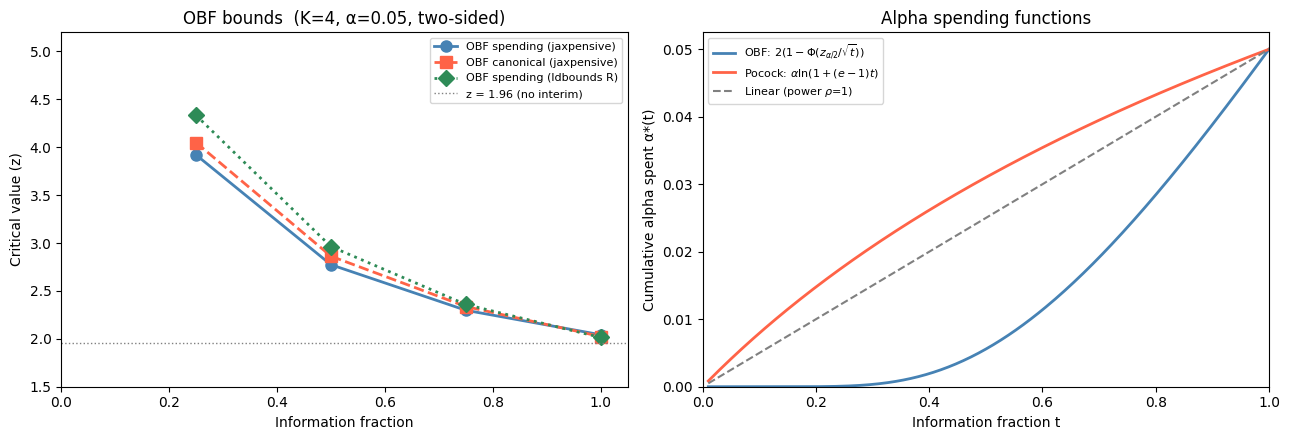

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: bounds at each look ---
ax = axes[0]
ax.plot(t, b_spend,   'o-', color='steelblue', lw=2, ms=8, label='OBF spending (jaxpensive)')
ax.plot(t, b_canon,   's--', color='tomato',   lw=2, ms=8, label='OBF canonical (jaxpensive)')
ax.plot(t, ldb_obf_k4,'D:',  color='seagreen', lw=2, ms=8, label='OBF spending (ldbounds R)')
ax.axhline(1.96, ls=':', color='gray', lw=1, label='z = 1.96 (no interim)')
ax.set_xlabel('Information fraction')
ax.set_ylabel('Critical value (z)')
ax.set_title('OBF bounds  (K=4, α=0.05, two-sided)')
ax.legend(fontsize=8)
ax.set_xlim(0, 1.05); ax.set_ylim(1.5, 5.2)

# --- Right: cumulative alpha spending curve ---
ax = axes[1]
t_grid = np.linspace(0.01, 1.0, 300)
z_ref  = norm.ppf(1 - alpha / 2)
f_obf  = 2 * (1 - norm.cdf(z_ref / np.sqrt(t_grid)))
f_poc  = alpha * np.log(1 + (np.e - 1) * t_grid)

ax.plot(t_grid, f_obf, color='steelblue', lw=2, label='OBF: $2(1-\\Phi(z_{\\alpha/2}/\\sqrt{t}))$')
ax.plot(t_grid, f_poc, color='tomato',    lw=2, label='Pocock: $\\alpha \\ln(1+(e-1)t)$')
ax.plot(t_grid, alpha * t_grid, color='gray', lw=1.5, ls='--', label='Linear (power $\\rho$=1)')
ax.set_xlabel('Information fraction t')
ax.set_ylabel('Cumulative alpha spent α*(t)')
ax.set_title('Alpha spending functions')
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, alpha * 1.05)

plt.tight_layout()
plt.show()

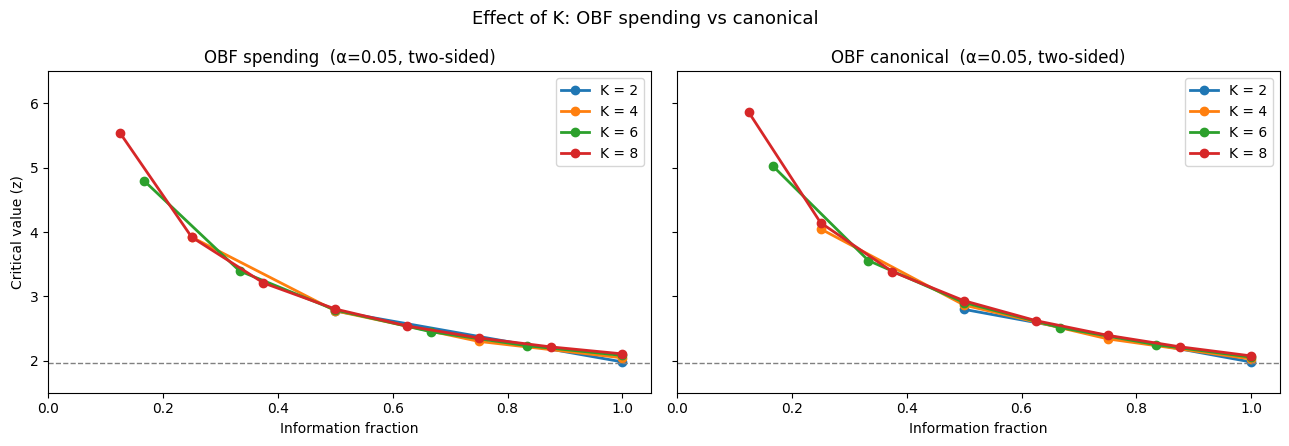

In [5]:
# OBF spending: effect of K, compare spending vs canonical
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for ax, label, cls, kw in [
    (axes[0], 'OBF spending',  AlphaSpendingBounds, dict(method='obf')),
    (axes[1], 'OBF canonical', CanonicalBounds,      dict(method='obrien_fleming')),
]:
    for k_looks, color in zip([2, 4, 6, 8], colors):
        b = cls(k_looks, 0.05, 2, **kw)
        ax.plot(b.info_fractions, b.calculate_bounds(),
                'o-', color=color, lw=2, ms=6, label=f'K = {k_looks}')
    ax.axhline(1.96, ls='--', color='gray', lw=1)
    ax.set_title(label + '  (α=0.05, two-sided)')
    ax.set_xlabel('Information fraction')
    ax.set_xlim(0, 1.05); ax.set_ylim(1.5, 6.5)
    ax.legend()

axes[0].set_ylabel('Critical value (z)')
plt.suptitle('Effect of K: OBF spending vs canonical', fontsize=13)
plt.tight_layout()
plt.show()

## Pocock Spending

The Pocock spending function is:

$$\alpha^*(t) = \alpha \cdot \ln\!\left(1 + (e - 1) \cdot t\right)$$

It spends alpha more evenly across looks, producing bounds that are nearly (but not exactly) constant — mirroring canonical Pocock boundaries.

The spending bounds use the same formula as `ldbounds` (R) for Pocock, so agreement is expected to be very close (< 0.001).

In [6]:
# --- Pocock spending vs canonical, K=4, alpha=0.05, two-sided ---
poc_spending  = AlphaSpendingBounds(K, alpha, 2, 'pocock')
poc_canonical = CanonicalBounds(K, alpha, 2, 'pocock')

b_poc_spend = poc_spending.calculate_bounds()
b_poc_canon = poc_canonical.calculate_bounds()

# ldbounds (R) reference — same Pocock formula as jaxpensive
ldb_poc_k4 = np.array([2.3683, 2.3675, 2.3581, 2.3500])

print('Pocock  K=4, alpha=0.05, two-sided')
print(f'{"Look":>4}  {"t":>6}  {"Spending":>10}  {"Canonical":>10}  {"ldbounds":>10}')
print('  ' + '-'*50)
for k in range(K):
    print(f'{k+1:>4}  {t[k]:>6.2f}  {b_poc_spend[k]:>10.4f}  {b_poc_canon[k]:>10.4f}  {ldb_poc_k4[k]:>10.4f}')

print()
print(f'Max |spending − canonical|: {np.max(np.abs(b_poc_spend - b_poc_canon)):.4f}')
print(f'Max |spending − ldbounds| : {np.max(np.abs(b_poc_spend - ldb_poc_k4)):.4f}')
print(f'Spending bound range (max−min): {b_poc_spend.max() - b_poc_spend.min():.4f}')

Pocock  K=4, alpha=0.05, two-sided
Look       t    Spending   Canonical    ldbounds
  --------------------------------------------------
   1    0.25      2.3683      2.3613      2.3683
   2    0.50      2.3675      2.3613      2.3675
   3    0.75      2.3582      2.3613      2.3581
   4    1.00      2.3500      2.3613      2.3500

Max |spending − canonical|: 0.0113
Max |spending − ldbounds| : 0.0001
Spending bound range (max−min): 0.0183


In [7]:
print('=== Spending ===')
poc_spending.summary()
print()
print('=== Canonical ===')
poc_canonical.summary()

=== Spending ===

Group Sequential Bounds — pocock
  Looks : 4
  Alpha : 0.05
  Sides : 2
  --------------------------------------------
  Look   Info fraction   Lower (z)   Upper (z)
  --------------------------------------------
     1          0.2500     -2.3683      2.3683
     2          0.5000     -2.3675      2.3675
     3          0.7500     -2.3582      2.3582
     4          1.0000     -2.3500      2.3500
  --------------------------------------------

=== Canonical ===



Group Sequential Bounds — pocock
  Looks : 4
  Alpha : 0.05
  Sides : 2
  --------------------------------------------
  Look   Info fraction   Lower (z)   Upper (z)
  --------------------------------------------
     1          0.2500     -2.3613      2.3613
     2          0.5000     -2.3613      2.3613
     3          0.7500     -2.3613      2.3613
     4          1.0000     -2.3613      2.3613
  --------------------------------------------


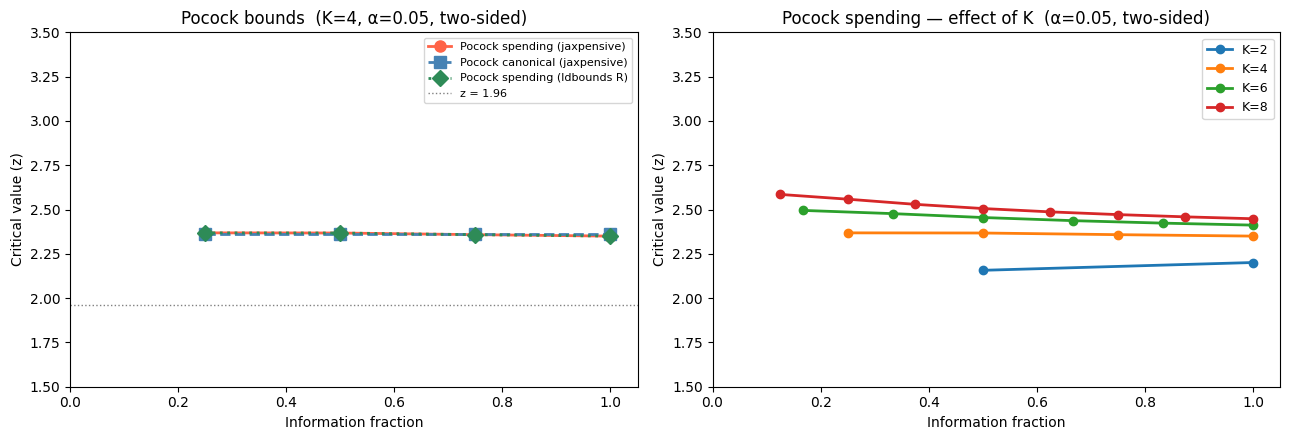

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: bounds comparison ---
ax = axes[0]
ax.plot(t, b_poc_spend,  'o-', color='tomato',   lw=2, ms=8, label='Pocock spending (jaxpensive)')
ax.plot(t, b_poc_canon,  's--', color='steelblue',lw=2, ms=8, label='Pocock canonical (jaxpensive)')
ax.plot(t, ldb_poc_k4,   'D:',  color='seagreen', lw=2, ms=8, label='Pocock spending (ldbounds R)')
ax.axhline(1.96, ls=':', color='gray', lw=1, label='z = 1.96')
ax.set_xlabel('Information fraction')
ax.set_ylabel('Critical value (z)')
ax.set_title('Pocock bounds  (K=4, α=0.05, two-sided)')
ax.legend(fontsize=8)
ax.set_xlim(0, 1.05); ax.set_ylim(1.5, 3.5)

# --- Right: nearly-constant property across K ---
ax = axes[1]
for k_looks, color in zip([2, 4, 6, 8], colors):
    b = AlphaSpendingBounds(k_looks, 0.05, 2, 'pocock')
    bounds = b.calculate_bounds()
    ax.plot(b.info_fractions, bounds, 'o-', color=color, lw=2, ms=6, label=f'K={k_looks}')

ax.set_xlabel('Information fraction')
ax.set_ylabel('Critical value (z)')
ax.set_title('Pocock spending — effect of K  (α=0.05, two-sided)')
ax.legend(fontsize=9)
ax.set_xlim(0, 1.05); ax.set_ylim(1.5, 3.5)

plt.tight_layout()
plt.show()

## OBF vs Pocock Side-by-Side

Both spending methods produce broadly the expected shapes, but neither matches canonical bounds exactly:

| Property | OBF spending | Pocock spending |
|---|---|---|
| Early bounds | Conservative | Roughly constant |
| Late bounds | ~Final z | ~Same as early |
| Match to canonical | Shape similar, values differ | Shape similar, nearly exact match to ldbounds |

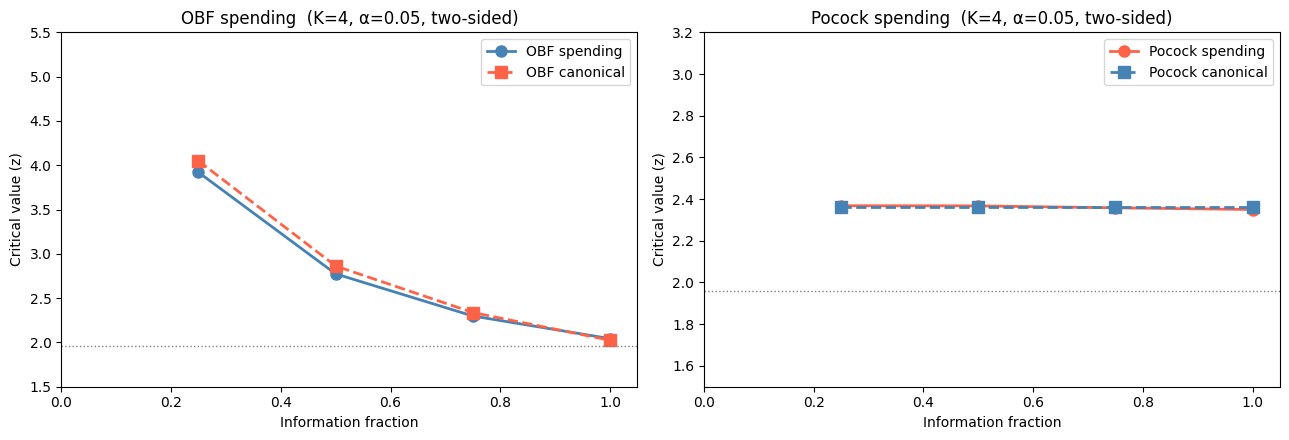

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, method, spend_label, canon_method, color_s, color_c, ylim in [
    (axes[0], 'obf',    'OBF spending',    'obrien_fleming', 'steelblue', 'tomato',    (1.5, 5.5)),
    (axes[1], 'pocock', 'Pocock spending', 'pocock',         'tomato',    'steelblue', (1.5, 3.2)),
]:
    b_s = AlphaSpendingBounds(4, 0.05, 2, method)
    b_c = CanonicalBounds(4, 0.05, 2, canon_method)
    ax.plot(b_s.info_fractions, b_s.calculate_bounds(),
            'o-', color=color_s, lw=2, ms=8, label=spend_label)
    ax.plot(b_c.info_fractions, b_c.calculate_bounds(),
            's--', color=color_c, lw=2, ms=8, label=f'{spend_label.split()[0]} canonical')
    ax.axhline(1.96, ls=':', color='gray', lw=1)
    ax.set_xlabel('Information fraction')
    ax.set_ylabel('Critical value (z)')
    ax.set_title(f'{spend_label}  (K=4, α=0.05, two-sided)')
    ax.legend()
    ax.set_xlim(0, 1.05); ax.set_ylim(*ylim)

plt.tight_layout()
plt.show()

## Unequally-Spaced Looks

A key advantage of the spending approach over canonical bounds: `info_fractions` can be non-uniform.
Canonical bounds require equally-spaced looks; spending bounds work with any schedule.

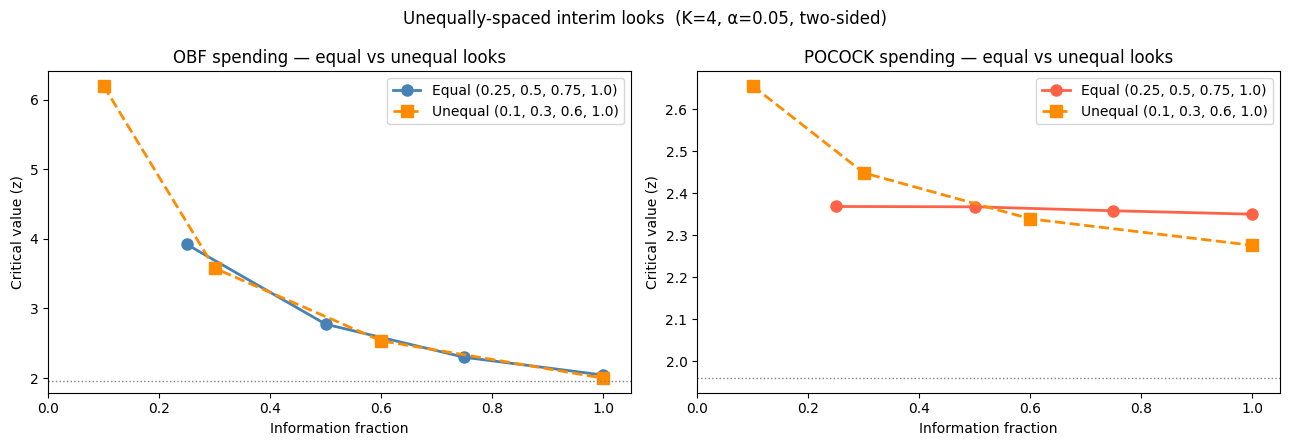

Unequal OBF spending bounds:    [2.6551 2.4484 2.3389 2.276 ]
Unequal Pocock spending bounds: [2.6551 2.4484 2.3389 2.276 ]


In [10]:
equal_fracs   = [0.25, 0.50, 0.75, 1.0]
unequal_fracs = [0.10, 0.30, 0.60, 1.0]   # front-loaded schedule

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, method, color in [
    (axes[0], 'obf',    'steelblue'),
    (axes[1], 'pocock', 'tomato'),
]:
    b_eq  = AlphaSpendingBounds(4, 0.05, 2, method, info_fractions=equal_fracs)
    b_ueq = AlphaSpendingBounds(4, 0.05, 2, method, info_fractions=unequal_fracs)

    ax.plot(equal_fracs,   b_eq.calculate_bounds(),  'o-',  color=color,       lw=2, ms=8, label='Equal (0.25, 0.5, 0.75, 1.0)')
    ax.plot(unequal_fracs, b_ueq.calculate_bounds(),  's--', color='darkorange', lw=2, ms=8, label='Unequal (0.1, 0.3, 0.6, 1.0)')
    ax.axhline(1.96, ls=':', color='gray', lw=1)
    ax.set_xlabel('Information fraction')
    ax.set_ylabel('Critical value (z)')
    ax.set_title(f'{method.upper()} spending — equal vs unequal looks')
    ax.legend()
    ax.set_xlim(0, 1.05)

plt.suptitle('Unequally-spaced interim looks  (K=4, α=0.05, two-sided)', fontsize=12)
plt.tight_layout()
plt.show()

print('Unequal OBF spending bounds:   ', np.round(b_ueq.calculate_bounds(), 4))
print('Unequal Pocock spending bounds:', np.round(
    AlphaSpendingBounds(4, 0.05, 2, 'pocock', info_fractions=unequal_fracs).calculate_bounds(), 4))

## Accuracy: GL n_nodes Convergence

The Gauss-Legendre quadrature converges exponentially for smooth integrands.
For Pocock and Power (where our spending formula matches `ldbounds` exactly),
we can measure convergence directly against the R reference values.

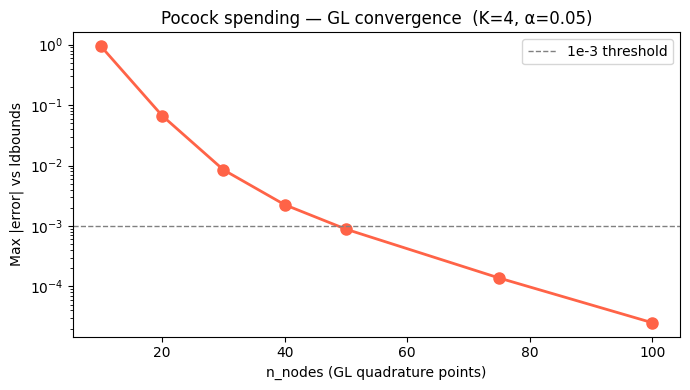

   n_nodes      max|err|
        10      0.945088
        20      0.066907
        30      0.008494
        40      0.002246
        50      0.000885
        75      0.000138
       100      0.000025


In [11]:
ldb_ref = np.array([2.3683, 2.3675, 2.3581, 2.3500])   # ldbounds Pocock K=4

n_vals  = [10, 20, 30, 40, 50, 75, 100]
errors  = []
for n in n_vals:
    b = AlphaSpendingBounds(4, 0.05, 2, 'pocock', n_nodes=n).calculate_bounds()
    errors.append(np.max(np.abs(b - ldb_ref)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(n_vals, errors, 'o-', color='tomato', lw=2, ms=8)
ax.axhline(1e-3, ls='--', color='gray', lw=1, label='1e-3 threshold')
ax.set_xlabel('n_nodes (GL quadrature points)')
ax.set_ylabel('Max |error| vs ldbounds')
ax.set_title('Pocock spending — GL convergence  (K=4, α=0.05)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'  {"n_nodes":>8}  {"max|err|":>12}')
for n, e in zip(n_vals, errors):
    print(f'  {n:>8}  {e:>12.6f}')

## One-Sided Tests

For one-sided tests the OBF spending formula is identical to `ldbounds`, so agreement is close (numerical algorithm differences only).

OBF spending, K=5, alpha=0.05, one-sided
Look       t    jaxpensive    ldbounds      diff
  ------------------------------------------------
   1    0.20        4.2291      4.2292   -0.0001
   2    0.40        2.8881      2.8881   +0.0000
   3    0.60        2.2981      2.2981   -0.0000
   4    0.80        1.9618      1.9618   +0.0000
   5    1.00        1.7397      1.7397   +0.0000

Max |diff|: 0.0001  (algorithm only — same formula)


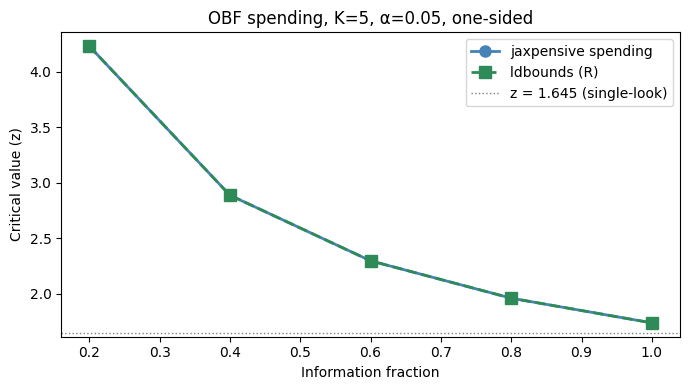

In [12]:
# OBF one-sided K=5: compare spending vs ldbounds reference
ldb_obf_k5_1s = np.array([4.2292, 2.8881, 2.2981, 1.9618, 1.7397])

b_1s = AlphaSpendingBounds(5, 0.05, 1, 'obf')
bounds_1s = b_1s.calculate_bounds()

print('OBF spending, K=5, alpha=0.05, one-sided')
print(f'{"Look":>4}  {"t":>6}  {"jaxpensive":>12}  {"ldbounds":>10}  {"diff":>8}')
print('  ' + '-'*48)
for k in range(5):
    diff = bounds_1s[k] - ldb_obf_k5_1s[k]
    print(f'{k+1:>4}  {b_1s.info_fractions[k]:>6.2f}  {bounds_1s[k]:>12.4f}  {ldb_obf_k5_1s[k]:>10.4f}  {diff:>+8.4f}')

print(f'\nMax |diff|: {np.max(np.abs(bounds_1s - ldb_obf_k5_1s)):.4f}  (algorithm only — same formula)')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(b_1s.info_fractions, bounds_1s,         'o-', color='steelblue', lw=2, ms=8, label='jaxpensive spending')
ax.plot(b_1s.info_fractions, ldb_obf_k5_1s,     's--', color='seagreen', lw=2, ms=8, label='ldbounds (R)')
ax.axhline(norm.ppf(0.95), ls=':', color='gray', lw=1, label='z = 1.645 (single-look)')
ax.set_xlabel('Information fraction')
ax.set_ylabel('Critical value (z)')
ax.set_title('OBF spending, K=5, α=0.05, one-sided')
ax.legend()
plt.tight_layout()
plt.show()

## Custom Spending Functions

Any spending function can be passed via `method='custom'` and `spending_fn=f` where
`f(t)` returns the cumulative alpha spent by information time `t`.
The function must satisfy `f(0) = 0` and `f(1) = alpha`.

### Hwang-Shih-DeCani family

A useful family not available as a built-in (it is `iuse=4` in `ldbounds`):

$$\alpha^*(t) = \alpha \cdot \frac{1 - e^{-\phi t}}{1 - e^{-\phi}}$$

- **φ < 0**: aggressive early spending (OBF-like)
- **φ → 0**: linear spending
- **φ > 0**: conservative early spending (back-loaded)

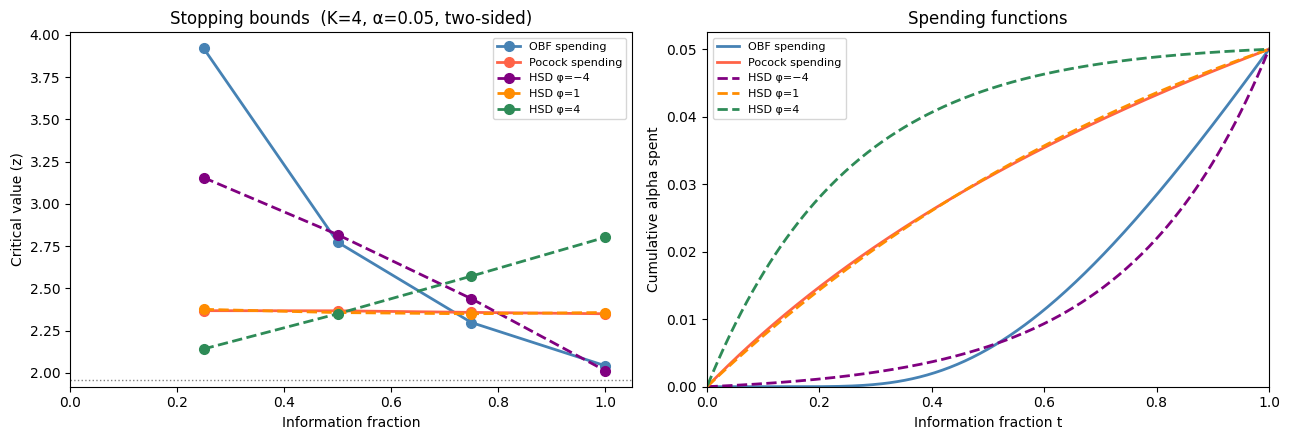

In [13]:
alpha = 0.05

def hwang_shih_decani(phi: float):
    """Return an HSD spending function with parameter phi."""
    def _hsd(t: float) -> float:
        if abs(phi) < 1e-8:          # limit phi -> 0 is linear
            return alpha * t
        return alpha * (1 - np.exp(-phi * t)) / (1 - np.exp(-phi))
    _hsd.__name__ = f'HSD(phi={phi})'
    return _hsd

# Three HSD variants + OBF and Pocock for comparison
configs = [
    ('OBF spending',    AlphaSpendingBounds(4, alpha, 2, 'obf'),          'steelblue', '-'),
    ('Pocock spending', AlphaSpendingBounds(4, alpha, 2, 'pocock'),        'tomato',    '-'),
    ('HSD φ=−4',        AlphaSpendingBounds(4, alpha, 2, 'custom',
                            spending_fn=hwang_shih_decani(-4)),           'purple',    '--'),
    ('HSD φ=1',         AlphaSpendingBounds(4, alpha, 2, 'custom',
                            spending_fn=hwang_shih_decani(1)),            'darkorange','--'),
    ('HSD φ=4',         AlphaSpendingBounds(4, alpha, 2, 'custom',
                            spending_fn=hwang_shih_decani(4)),            'seagreen',  '--'),
]

t_vals = [0.25, 0.5, 0.75, 1.0]
t_grid = np.linspace(0.001, 1.0, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: stopping bounds at each look
ax = axes[0]
for label, b, color, ls in configs:
    bounds = b.calculate_bounds()
    ax.plot(t_vals, bounds, f'o{ls}', color=color, lw=2, ms=7, label=label)
ax.axhline(1.96, ls=':', color='gray', lw=1)
ax.set_xlabel('Information fraction')
ax.set_ylabel('Critical value (z)')
ax.set_title('Stopping bounds  (K=4, α=0.05, two-sided)')
ax.legend(fontsize=8)
ax.set_xlim(0, 1.05)

# Right: spending curves
ax = axes[1]
for label, b, color, ls in configs:
    if b.method == 'custom':
        f_vals = [b._cumulative_spend(t) for t in t_grid]
    elif b.method == 'obf':
        from scipy.stats import norm as _norm
        z = _norm.ppf(1 - alpha/2)
        f_vals = [min(2*(1-_norm.cdf(z/np.sqrt(t))), alpha) for t in t_grid]
    else:  # pocock
        f_vals = [alpha * np.log(1 + (np.e-1)*t) for t in t_grid]
    ax.plot(t_grid, f_vals, color=color, lw=2, ls=ls.replace('o',''), label=label)
ax.set_xlabel('Information fraction t')
ax.set_ylabel('Cumulative alpha spent')
ax.set_title('Spending functions')
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, alpha * 1.05)

plt.tight_layout()
plt.show()

### Bounds table: all five methods

In [14]:
print(f'  {"Method":<20}' + ''.join(f'  Look {k+1}' for k in range(4)))
print('  ' + '-'*56)
for label, b, _, _ in configs:
    bounds = np.round(b.calculate_bounds(), 4)
    row = '  '.join(f'{v:>8.4f}' for v in bounds)
    print(f'  {label:<20}  {row}')

print()
print('repr examples:')
for _, b, _, _ in configs[-3:]:
    print(' ', repr(b))

  Method                Look 1  Look 2  Look 3  Look 4
  --------------------------------------------------------
  OBF spending            3.9199    2.7739    2.2982    2.0426
  Pocock spending         2.3683    2.3675    2.3582    2.3500
  HSD φ=−4                3.1553    2.8183    2.4391    2.0136
  HSD φ=1                 2.3761    2.3571    2.3499    2.3574
  HSD φ=4                 2.1420    2.3499    2.5727    2.8023

repr examples:
  AlphaSpendingBounds(reads=4, alpha=0.05, sides=2, method='custom', spending_fn='HSD(phi=-4)')
  AlphaSpendingBounds(reads=4, alpha=0.05, sides=2, method='custom', spending_fn='HSD(phi=1)')
  AlphaSpendingBounds(reads=4, alpha=0.05, sides=2, method='custom', spending_fn='HSD(phi=4)')


## Discrepancies between O'Brien-Fleming bound in ldbounds and jaxpensive in 2 sided design

A point of note that initially seemed strange, but has ultimately resolved are bounds calculated for a 2 sided alpha spending design using O'Brien-Fleming bounds.  Let's compare the output of the two calculations.

In [4]:
jaxpensive_bounds_obf = AlphaSpendingBounds(4, 0.05, 2, 'obf')
jaxpensive_bounds_obf.summary()


Group Sequential Bounds — obf
  Looks : 4
  Alpha : 0.05
  Sides : 2
  --------------------------------------------
  Look   Info fraction   Lower (z)   Upper (z)
  --------------------------------------------
     1          0.2500     -3.9199      3.9199
     2          0.5000     -2.7739      2.7739
     3          0.7500     -2.2982      2.2982
     4          1.0000     -2.0426      2.0426
  --------------------------------------------


Not this is not the same as if you are to call R which would give you the following table:

| Time | Lower      | Upper      |
|------|------------|------------|
| 0.25 | -4.332634  |  4.332634  |
| 0.50 | -2.963112  |  2.963112  |
| 0.75 | -2.359023  |  2.359023  |
| 1.00 | -2.014059  |  2.014059  |

From this we can consider 2 questions: 

1. Does the calculation given by jaxpensive do what it intends (control total alpha at 0.05)
2. Can we recover the bounds provided by ldbounds using a custom spending function.

The below block of code addresses question 1 the total alpha is in fact controlled at our specified level.

In [16]:
bounds = jaxpensive_bounds_obf.calculate_bounds()
Sigma = jaxpensive_bounds_obf._covariance_matrix()
2*(1-multivariate_normal.cdf(bounds, mean=np.zeros(4), cov=Sigma)).item()

0.05000089394320306

The below block of code addresses question 2 that we can recover the bounds of calculated by ldbounds.  Effectively the spending functions are subtlely different.  Here is obrien-fleming calculation jaxpensive is doing:

```python
z = norm.ppf(1.0 - self.alpha / 2.0)
return float(min(2.0 * (1.0 - norm.cdf(z / np.sqrt(t))), self.alpha))
```

Contrasting the 2 spending functions you can see ldbounds accomodates the number of sides, so the spending function is different.  Per the z-values ldbounds saves it's alpha in the beginning so it can spend more in the end.  Both are pefectly valid, just slightly different.

In [11]:
alpha = 0.05  # must match the alpha you pass to AlphaSpendingBounds
sides = 2     # must match sides

z = norm.ppf(1 - alpha / (2 * sides))

def ldbounds_obf_spending(t: float) -> float:
    if t <= 0.0:
        return 0.0
    return float(min(2 * sides * (1 - norm.cdf(z / np.sqrt(t))), alpha))

jaxpensive_ldbounds_obf = AlphaSpendingBounds(4, alpha, sides, "custom", spending_fn=ldbounds_obf_spending)

jaxpensive_ldbounds_obf.summary()



Group Sequential Bounds — custom
  Looks : 4
  Alpha : 0.05
  Sides : 2
  --------------------------------------------
  Look   Info fraction   Lower (z)   Upper (z)
  --------------------------------------------
     1          0.2500     -4.3326      4.3326
     2          0.5000     -2.9631      2.9631
     3          0.7500     -2.3590      2.3590
     4          1.0000     -2.0141      2.0141
  --------------------------------------------
